In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("/Users/disastershubz/Desktop/loan data/loan.csv")

/var/folders/g4/nw3tvq1j6q7c8jjlxwf19c5c0000gn/T/ipykernel_20348/2356434558.py:1: DtypeWarning: Columns (19,47,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/disastershubz/Desktop/loan data/loan.csv")


In [5]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.shape

(2260668, 145)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), object(36)
memory usage: 2.4+ GB


In [8]:
print("duplicate column names:", df.columns[df.columns.duplicated()].tolist())

duplicate column names: []


In [9]:
print("nulls (total):", int(df.isna().sum().sum()))


nulls (total): 108666958


In [10]:
print("top dtypes:\n", df.dtypes.value_counts())


top dtypes:
 float64    105
object      36
int64        4
Name: count, dtype: int64


In [11]:
df.columns = (
    pd.Index(df.columns)
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)

print("columns count:", len(df.columns))
print("duplicate column names:", df.columns[df.columns.duplicated()].tolist())


columns count: 145
duplicate column names: []


In [12]:
null_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

print(null_summary.head(15))   # top 15 columns with most nulls


id                                            2260668
url                                           2260668
member_id                                     2260668
orig_projected_additional_accrued_interest    2252242
hardship_length                               2250055
hardship_reason                               2250055
hardship_status                               2250055
deferral_term                                 2250055
hardship_amount                               2250055
hardship_start_date                           2250055
hardship_end_date                             2250055
payment_plan_start_date                       2250055
hardship_dpd                                  2250055
hardship_loan_status                          2250055
hardship_payoff_balance_amount                2250055
dtype: int64


In [13]:
null_percent = (df.isna().mean() * 100).round(2)
print(null_percent.sort_values(ascending=False).head(15))


id                                            100.00
url                                           100.00
member_id                                     100.00
orig_projected_additional_accrued_interest     99.63
hardship_length                                99.53
hardship_reason                                99.53
hardship_status                                99.53
deferral_term                                  99.53
hardship_amount                                99.53
hardship_start_date                            99.53
hardship_end_date                              99.53
payment_plan_start_date                        99.53
hardship_dpd                                   99.53
hardship_loan_status                           99.53
hardship_payoff_balance_amount                 99.53
dtype: float64


STEP 3: Standardize null-like values (NOW DO THIS)

In [14]:
import numpy as np

NULL_LIKE = ["", " ", "na", "n/a", "null", "none", "nan", "-999", "-1"]

obj_cols = df.select_dtypes(include=["object"]).columns

df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())
df.replace(NULL_LIKE, np.nan, inplace=True)

print("nulls (total) after standardization:", int(df.isna().sum().sum()))


nulls (total) after standardization: 108667223


In [15]:
 null_pct = df.isna().mean() * 100

flag_cols = null_pct[(null_pct >= 5) & (null_pct <= 95)].index.tolist()

print("Number of columns eligible for missing flags:", len(flag_cols))
print(flag_cols[:10])  # preview first 10


Number of columns eligible for missing flags: 29
['emp_title', 'emp_length', 'desc', 'mths_since_last_delinq', 'mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint']


In [16]:
for col in flag_cols:
    df[f"{col}_is_missing"] = df[col].isna().astype("int8")

print("New shape after adding flags:", df.shape)


New shape after adding flags: (2260668, 174)


In [17]:
full_null_cols = df.columns[df.isna().all()].tolist()

print("100% null columns count:", len(full_null_cols))
print(full_null_cols)


100% null columns count: 3
['id', 'member_id', 'url']


In [18]:
df.drop(columns=full_null_cols, inplace=True)

print("Shape after dropping 100% null columns:", df.shape)


Shape after dropping 100% null columns: (2260668, 171)


In [19]:
obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Object columns count:", len(obj_cols))
obj_cols


Object columns count: 36


['term',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'last_pymnt_d',
 'next_pymnt_d',
 'last_credit_pull_d',
 'application_type',
 'verification_status_joint',
 'sec_app_earliest_cr_line',
 'hardship_flag',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'hardship_start_date',
 'hardship_end_date',
 'payment_plan_start_date',
 'hardship_loan_status',
 'disbursement_method',
 'debt_settlement_flag',
 'debt_settlement_flag_date',
 'settlement_status',
 'settlement_date']

In [20]:
# convert term to numeric months
df["term"] = (
    df["term"]
    .str.extract(r"(\d+)")
    .astype("float64")
)

print(df["term"].dtype)
print(df["term"].isna().sum())


float64
0


In [21]:
date_cols = [
    "issue_d",
    "earliest_cr_line",
    "last_pymnt_d",
    "next_pymnt_d",
    "last_credit_pull_d",
    "sec_app_earliest_cr_line",
    "hardship_start_date",
    "hardship_end_date",
    "payment_plan_start_date",
    "debt_settlement_flag_date",
    "settlement_date"
]


In [22]:
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

print(df[date_cols].dtypes)


/var/folders/g4/nw3tvq1j6q7c8jjlxwf19c5c0000gn/T/ipykernel_20348/743673398.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/var/folders/g4/nw3tvq1j6q7c8jjlxwf19c5c0000gn/T/ipykernel_20348/743673398.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/var/folders/g4/nw3tvq1j6q7c8jjlxwf19c5c0000gn/T/ipykernel_20348/743673398.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/var/folders/g4/nw3tvq1j6q7c8jjlxwf19c5c0000gn

issue_d                      datetime64[ns]
earliest_cr_line             datetime64[ns]
last_pymnt_d                 datetime64[ns]
next_pymnt_d                 datetime64[ns]
last_credit_pull_d           datetime64[ns]
sec_app_earliest_cr_line     datetime64[ns]
hardship_start_date          datetime64[ns]
hardship_end_date            datetime64[ns]
payment_plan_start_date      datetime64[ns]
debt_settlement_flag_date    datetime64[ns]
settlement_date              datetime64[ns]
dtype: object


In [23]:
bool_cols = [
    "pymnt_plan",
    "hardship_flag",
    "debt_settlement_flag"
]


In [24]:
for col in bool_cols:
    if col in df.columns:
        print(col, df[col].dropna().unique())


pymnt_plan ['n' 'y']
hardship_flag ['N' 'Y']
debt_settlement_flag ['N' 'Y']


In [25]:
binary_map = {
    "pymnt_plan": {"y": 1, "n": 0},
    "hardship_flag": {"Y": 1, "N": 0},
    "debt_settlement_flag": {"Y": 1, "N": 0},
}

for col, mapping in binary_map.items():
    if col in df.columns:
        df[col] = df[col].map(mapping).astype("int8")

print(df[["pymnt_plan", "hardship_flag", "debt_settlement_flag"]].dtypes)
print(df[["pymnt_plan", "hardship_flag", "debt_settlement_flag"]].isna().sum())


pymnt_plan              int8
hardship_flag           int8
debt_settlement_flag    int8
dtype: object
pymnt_plan              0
hardship_flag           0
debt_settlement_flag    0
dtype: int64


In [26]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns count:", len(cat_cols))
cat_cols


Categorical columns count: 21


['grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'verification_status',
 'loan_status',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'initial_list_status',
 'application_type',
 'verification_status_joint',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'hardship_loan_status',
 'disbursement_method',
 'settlement_status']

In [27]:
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

print("Sample check:")
for col in cat_cols[:5]:
    print(col, df[col].dropna().unique()[:5])


Sample check:
grade ['c' 'd' 'b' 'a' 'e']
sub_grade ['c1' 'd2' 'd1' 'c4' 'c3']
emp_title ['chef' 'postmaster' 'administrative' 'it supervisor' 'mechanic']
emp_length ['10+ years' '6 years' '4 years' '< 1 year' '2 years']
home_ownership ['rent' 'mortgage' 'own' 'any' 'none']


In [28]:
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
print("Numeric columns count:", len(num_cols))
num_cols


Numeric columns count: 139


['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'annual_inc',
 'pymnt_plan',
 'dti',
 'delinq_2yrs',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'annual_inc_joint',
 'dti_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 

In [29]:

neg_check = {}

for col in num_cols:
    if df[col].min(skipna=True) < 0:
        neg_check[col] = df[col].min(skipna=True)

len(neg_check), list(neg_check.items())[:10]


(2, [('dti', np.float64(-1.0)), ('total_rec_late_fee', np.float64(-9.5e-09))])

In [30]:

# dti: -1 means not available
df.loc[df["dti"] < 0, "dti"] = np.nan

# floating point noise → 0
df["total_rec_late_fee"] = df["total_rec_late_fee"].clip(lower=0)

print("dti negatives after fix:", (df["dti"] < 0).sum())
print("min total_rec_late_fee:", df["total_rec_late_fee"].min())


dti negatives after fix: 0
min total_rec_late_fee: 0.0


In [31]:
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)


Duplicate rows: 0


In [32]:
print("Final shape:", df.shape)
print("\nDtypes summary:")
print(df.dtypes.value_counts())

print("\nTotal nulls:", int(df.isna().sum().sum()))


Final shape: (2260668, 171)

Dtypes summary:
float64           103
int8               32
object             21
datetime64[ns]     11
int64               4
Name: count, dtype: int64

Total nulls: 101885221


In [33]:
# candidate columns that are usually not useful for modeling
non_ml_candidates = [
    "emp_title",
    "desc",
    "title",
    "zip_code"
]

print("Present in df:")
[col for col in non_ml_candidates if col in df.columns]


Present in df:


['emp_title', 'desc', 'title', 'zip_code']

In [34]:
drop_cols = ["emp_title", "desc", "title", "zip_code"]
drop_cols += [f"{c}_is_missing" for c in drop_cols if f"{c}_is_missing" in df.columns]

print("Dropping:", drop_cols)

df.drop(columns=drop_cols, inplace=True)

print("Shape after drop:", df.shape)


Dropping: ['emp_title', 'desc', 'title', 'zip_code', 'emp_title_is_missing', 'desc_is_missing']
Shape after drop: (2260668, 165)


In [35]:
null_pct = (df.isna().mean() * 100).round(2)

ultra_sparse = null_pct[null_pct >= 99].sort_values(ascending=False)

print("Ultra-sparse (>=99% null) columns:", len(ultra_sparse))
print(ultra_sparse.head(30))


Ultra-sparse (>=99% null) columns: 14
orig_projected_additional_accrued_interest    99.63
hardship_type                                 99.53
hardship_reason                               99.53
hardship_status                               99.53
deferral_term                                 99.53
hardship_amount                               99.53
hardship_start_date                           99.53
hardship_end_date                             99.53
payment_plan_start_date                       99.53
hardship_length                               99.53
hardship_dpd                                  99.53
hardship_loan_status                          99.53
hardship_payoff_balance_amount                99.53
hardship_last_payment_amount                  99.53
dtype: float64


In [36]:
ultra_sparse_cols = ultra_sparse.index.tolist()

# also drop missingness flags for these cols if they exist
ultra_sparse_flags = [f"{c}_is_missing" for c in ultra_sparse_cols if f"{c}_is_missing" in df.columns]

print("Dropping ultra-sparse cols:", ultra_sparse_cols)
print("Dropping their flags (if any):", ultra_sparse_flags)

df.drop(columns=ultra_sparse_cols + ultra_sparse_flags, inplace=True)

print("Shape after dropping ultra-sparse cols:", df.shape)


Dropping ultra-sparse cols: ['orig_projected_additional_accrued_interest', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount']
Dropping their flags (if any): []
Shape after dropping ultra-sparse cols: (2260668, 151)


In [37]:
const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]

print("Constant columns count:", len(const_cols))
print(const_cols)


Constant columns count: 1
['policy_code']


In [38]:
df.drop(columns=["policy_code"], inplace=True)
print("Shape after dropping constant cols:", df.shape)


Shape after dropping constant cols: (2260668, 150)


In [39]:
pairs = [
    ("funded_amnt", "funded_amnt_inv"),
    ("total_pymnt", "total_pymnt_inv"),
    ("out_prncp", "out_prncp_inv"),
]

for a, b in pairs:
    if a in df.columns and b in df.columns:
        corr = df[[a, b]].corr().iloc[0, 1]
        print(f"{a} vs {b} correlation:", corr)


funded_amnt vs funded_amnt_inv correlation: 0.9993413347146661
total_pymnt vs total_pymnt_inv correlation: 0.9993944125282568
out_prncp vs out_prncp_inv correlation: 0.9999987211049428


In [40]:
redundant_cols = ["funded_amnt_inv", "total_pymnt_inv", "out_prncp_inv"]

df.drop(columns=redundant_cols, inplace=True)

print("Dropped:", redundant_cols)
print("Shape after dropping redundant cols:", df.shape)


Dropped: ['funded_amnt_inv', 'total_pymnt_inv', 'out_prncp_inv']
Shape after dropping redundant cols: (2260668, 147)


In [41]:
print("loan_status unique values (sample):")
print(df["loan_status"].value_counts().head(15))


loan_status unique values (sample):
loan_status
fully paid                                             1041952
current                                                 919695
charged off                                             261655
late (31-120 days)                                       21897
in grace period                                           8952
late (16-30 days)                                         3737
does not meet the credit policy. status:fully paid        1988
does not meet the credit policy. status:charged off        761
default                                                     31
Name: count, dtype: int64


In [42]:
leakage_keywords = [
    "pymnt", "rec_", "recover", "collection", "last_pymnt", "next_pymnt",
    "out_prncp", "settlement", "hardship"
]

leakage_cols = [c for c in df.columns if any(k in c for k in leakage_keywords)]

print("Leakage-like columns found:", len(leakage_cols))
print(leakage_cols)


Leakage-like columns found: 23
['pymnt_plan', 'out_prncp', 'total_pymnt', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'collections_12_mths_ex_med', 'pub_rec_bankruptcies', 'sec_app_collections_12_mths_ex_med', 'hardship_flag', 'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status', 'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term', 'next_pymnt_d_is_missing']


In [43]:
leakage_drop = [
    "pymnt_plan",
    "out_prncp",
    "total_pymnt",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "next_pymnt_d",
    "hardship_flag",
    "debt_settlement_flag",
    "debt_settlement_flag_date",
    "settlement_status",
    "settlement_date",
    "settlement_amount",
    "settlement_percentage",
    "settlement_term",
    "next_pymnt_d_is_missing",
]

df.drop(columns=[c for c in leakage_drop if c in df.columns], inplace=True)

print("Dropped leakage cols:", len(leakage_drop))
print("Shape after leakage drop:", df.shape)


Dropped leakage cols: 20
Shape after leakage drop: (2260668, 127)


In [44]:
print("Final shape:", df.shape)
print("Null % top 10:")
print((df.isna().mean()*100).round(2).sort_values(ascending=False).head(10))


Final shape: (2260668, 127)
Null % top 10:
sec_app_mths_since_last_major_derog    98.41
sec_app_revol_util                     95.30
sec_app_collections_12_mths_ex_med     95.22
sec_app_chargeoff_within_12_mths       95.22
sec_app_num_rev_accts                  95.22
sec_app_open_act_il                    95.22
sec_app_open_acc                       95.22
sec_app_mort_acc                       95.22
sec_app_inq_last_6mths                 95.22
sec_app_earliest_cr_line               95.22
dtype: float64


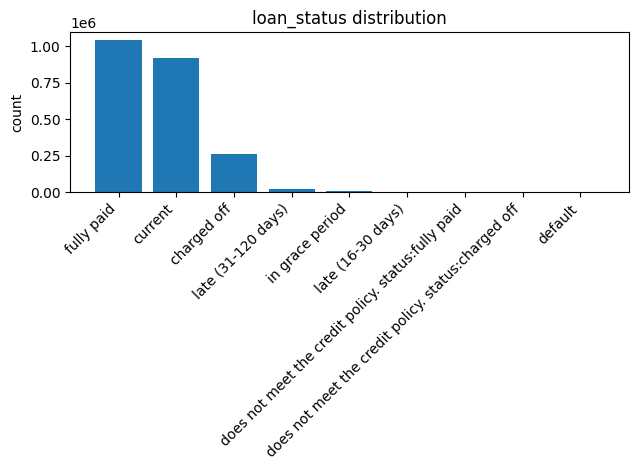

In [45]:
import matplotlib.pyplot as plt

vc = df["loan_status"].value_counts()

plt.figure()
plt.bar(vc.index.astype(str), vc.values)
plt.xticks(rotation=45, ha="right")
plt.title("loan_status distribution")
plt.ylabel("count")
plt.tight_layout()
plt.show()


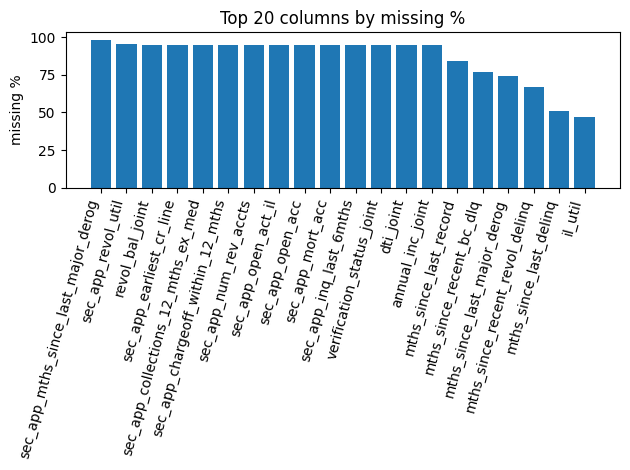

In [46]:
import matplotlib.pyplot as plt

null_pct = (df.isna().mean() * 100).sort_values(ascending=False).head(20)

plt.figure()
plt.bar(null_pct.index.astype(str), null_pct.values)
plt.xticks(rotation=75, ha="right")
plt.title("Top 20 columns by missing %")
plt.ylabel("missing %")
plt.tight_layout()
plt.show()


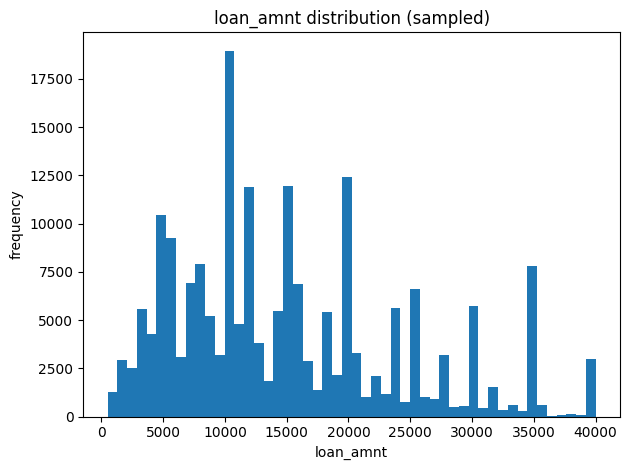

In [47]:
import matplotlib.pyplot as plt

s = df["loan_amnt"].dropna().sample(n=min(200_000, df["loan_amnt"].dropna().shape[0]), random_state=42)

plt.figure()
plt.hist(s, bins=50)
plt.title("loan_amnt distribution (sampled)")
plt.xlabel("loan_amnt")
plt.ylabel("frequency")
plt.tight_layout()
plt.show()


/var/folders/g4/nw3tvq1j6q7c8jjlxwf19c5c0000gn/T/ipykernel_20348/812029903.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


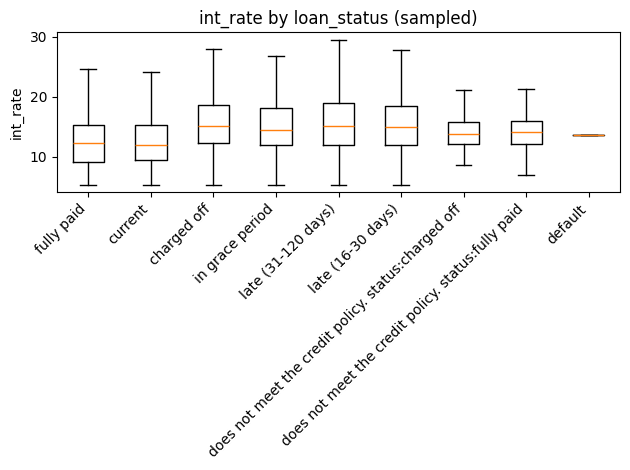

In [48]:
import matplotlib.pyplot as plt

tmp = df[["loan_status", "int_rate"]].dropna()
tmp = tmp.sample(n=min(200_000, len(tmp)), random_state=42)

groups = [tmp.loc[tmp["loan_status"] == k, "int_rate"].values for k in tmp["loan_status"].unique()]
labels = [str(k) for k in tmp["loan_status"].unique()]

plt.figure()
plt.boxplot(groups, labels=labels, showfliers=False)
plt.xticks(rotation=45, ha="right")
plt.title("int_rate by loan_status (sampled)")
plt.ylabel("int_rate")
plt.tight_layout()
plt.show()


target_bad
0.0    1041952
NaN     957030
1.0     261686
Name: count, dtype: int64


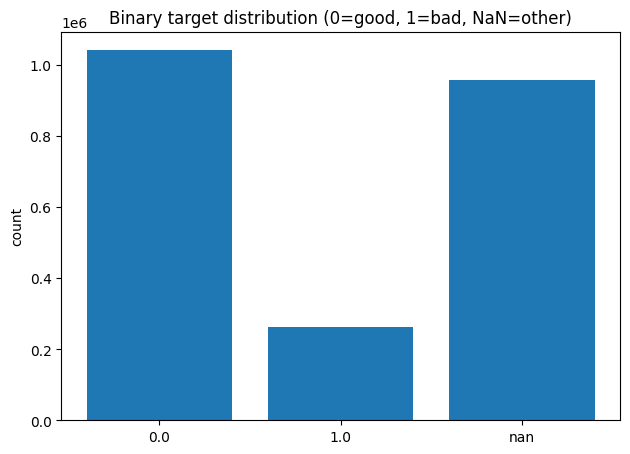

In [49]:
import numpy as np
import matplotlib.pyplot as plt

bad = {"charged off", "default"}
good = {"fully paid"}

df["target_bad"] = np.where(df["loan_status"].isin(bad), 1,
                    np.where(df["loan_status"].isin(good), 0, np.nan))

print(df["target_bad"].value_counts(dropna=False))

vc = df["target_bad"].value_counts(dropna=False).sort_index()

plt.figure()
plt.bar(vc.index.astype(str), vc.values)
plt.title("Binary target distribution (0=good, 1=bad, NaN=other)")
plt.ylabel("count")
plt.tight_layout()
plt.show()


In [50]:
sec_cols = [c for c in df.columns if c.startswith("sec_app_")]
sec_nonnull_rows = df[sec_cols].notna().any(axis=1).mean() * 100

print("sec_app_* columns:", len(sec_cols))
print("Rows with ANY sec_app_* value (%):", round(sec_nonnull_rows, 2))


sec_app_* columns: 10
Rows with ANY sec_app_* value (%): 4.78


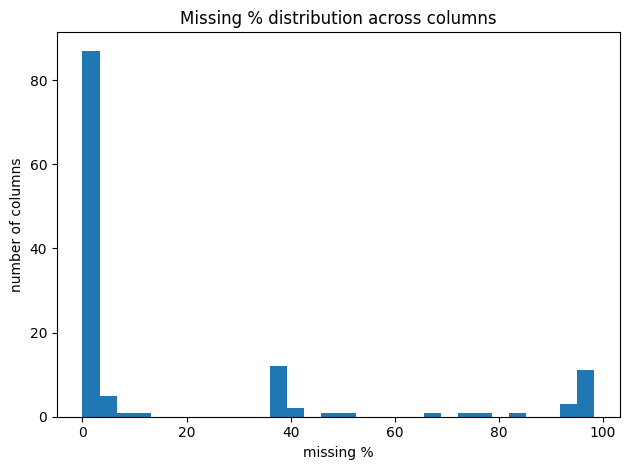

In [51]:
null_pct_all = (df.isna().mean() * 100).values

plt.figure()
plt.hist(null_pct_all, bins=30)
plt.title("Missing % distribution across columns")
plt.xlabel("missing %")
plt.ylabel("number of columns")
plt.tight_layout()
plt.show()


In [52]:
model_df = df[df["target_bad"].notna()].copy()

print("model_df shape:", model_df.shape)
print(model_df["target_bad"].value_counts())


model_df shape: (1303638, 128)
target_bad
0.0    1041952
1.0     261686
Name: count, dtype: int64


In [53]:
sec_cols = [c for c in df.columns if c.startswith("sec_app_")]
pct = model_df[sec_cols].notna().any(axis=1).mean() * 100

print("sec_app_* cols:", len(sec_cols))
print("rows with any sec_app_* present (%):", round(pct, 2))


sec_app_* cols: 10
rows with any sec_app_* present (%): 1.27


In [54]:
sec_cols = [c for c in model_df.columns if c.startswith("sec_app_")]
sec_flags = [c for c in model_df.columns if c.startswith("sec_app_") and c.endswith("_is_missing")]

print("Dropping sec_app cols:", sec_cols)
print("Dropping sec_app flags:", sec_flags)

model_df.drop(columns=sec_cols + sec_flags, inplace=True)

print("Shape after dropping sec_app_*:", model_df.shape)


Dropping sec_app cols: ['sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog']
Dropping sec_app flags: []
Shape after dropping sec_app_*: (1303638, 118)


In [55]:
from sklearn.model_selection import train_test_split

y = model_df["target_bad"].astype(int)
X = model_df.drop(columns=["target_bad", "loan_status"])

print("X shape:", X.shape)
print("y mean (bad rate):", y.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("train shapes:", X_train.shape, y_train.shape)
print("test shapes:", X_test.shape, y_test.shape)


X shape: (1303638, 116)
y mean (bad rate): 0.20073517341470562
train shapes: (1042910, 116) (1042910,)
test shapes: (260728, 116) (260728,)


In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

num_cols = X_train.select_dtypes(include=["number"]).columns
cat_cols = X_train.select_dtypes(exclude=["number"]).columns

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

clf = LogisticRegression(max_iter=200, class_weight="balanced", n_jobs=-1)

model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", clf)
])

model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))


/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ROC AUC: 0.6288097318964612
              precision    recall  f1-score   support

           0     0.8579    0.5421    0.6644    208391
           1     0.2605    0.6423    0.3707     52337

    accuracy                         0.5622    260728
   macro avg     0.5592    0.5922    0.5175    260728
weighted avg     0.7380    0.5622    0.6054    260728

Confusion matrix:
 [[112971  95420]
 [ 18719  33618]]


In [58]:
from sklearn.model_selection import train_test_split

X_tr_s, _, y_tr_s, _ = train_test_split(
    X_train, y_train,
    train_size=200_000,   # fast baseline
    random_state=42,
    stratify=y_train
)

print(X_tr_s.shape, y_tr_s.mean())



(200000, 116) 0.200735


In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

clf_fast = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    solver="lbfgs",
    n_jobs=-1
)

model_fast = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", clf_fast)
])

model_fast.fit(X_tr_s, y_tr_s)

proba = model_fast.predict_proba(X_test)[:, 1]
print("ROC AUC:", roc_auc_score(y_test, proba))


/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ROC AUC: 0.6376392412062046


In [60]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Keep only numeric features (fast + strong baseline)
Xn_train = X_train.select_dtypes(include=["number"])
Xn_test  = X_test.select_dtypes(include=["number"])

hgb = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=300,
    random_state=42
)

hgb.fit(Xn_train, y_train)

proba = hgb.predict_proba(Xn_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))


ROC AUC: 0.7297207432063761
              precision    recall  f1-score   support

           0     0.8126    0.9816    0.8891    208391
           1     0.5737    0.0986    0.1684     52337

    accuracy                         0.8044    260728
   macro avg     0.6932    0.5401    0.5287    260728
weighted avg     0.7647    0.8044    0.7445    260728

Confusion matrix:
 [[204555   3836]
 [ 47174   5163]]


In [61]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

thresholds = np.linspace(0.05, 0.50, 10)

for t in thresholds:
    pred_t = (proba >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred_t, average="binary", zero_division=0)
    print(f"thr={t:.2f}  precision={p:.3f}  recall={r:.3f}  f1={f1:.3f}")


thr=0.05  precision=0.216  recall=0.988  f1=0.354
thr=0.10  precision=0.250  recall=0.924  f1=0.393
thr=0.15  precision=0.289  recall=0.815  f1=0.426
thr=0.20  precision=0.328  recall=0.684  f1=0.444
thr=0.25  precision=0.369  recall=0.550  f1=0.442
thr=0.30  precision=0.411  recall=0.429  f1=0.420
thr=0.35  precision=0.453  recall=0.323  f1=0.377
thr=0.40  precision=0.493  recall=0.232  f1=0.316
thr=0.45  precision=0.533  recall=0.157  f1=0.243
thr=0.50  precision=0.574  recall=0.099  f1=0.168


In [62]:
from sklearn.metrics import confusion_matrix, classification_report

t = 0.20
pred20 = (proba >= t).astype(int)

print("Threshold:", t)
print(classification_report(y_test, pred20, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred20))


Threshold: 0.2
              precision    recall  f1-score   support

           0     0.8909    0.6486    0.7507    208391
           1     0.3282    0.6836    0.4435     52337

    accuracy                         0.6556    260728
   macro avg     0.6096    0.6661    0.5971    260728
weighted avg     0.7779    0.6556    0.6890    260728

Confusion matrix:
 [[135166  73225]
 [ 16558  35779]]
